In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('spam.csv')
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
df.groupby('Category').describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [4]:
df['Group'] = df['Category'].apply(lambda x: 1 if x=='spam' else 0)
df.head()

,Category,Message,Group
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [5]:
X = df.Message
y = df.Group

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3)

In [7]:
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

3900
1672
3900
1672


In [8]:
from sklearn.feature_extraction.text import CountVectorizer

In [9]:
vect = CountVectorizer()
X_train_vect = vect.fit_transform(X_train.values)
X_test_vect = vect.transform(X_test.values)
print(X_train_vect.toarray()[:3])
print('\r')
print(X_test_vect.toarray()[:3])

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [10]:
model = MultinomialNB()
model.fit(X_train_vect,y_train)
model.score(X_test_vect,y_test)

0.986244019138756

In [11]:
y_pred = model.predict(X_test_vect)
y_pred[:5]

array([0, 0, 0, 0, 1])

In [12]:
y_test[:5]

4304    0
662     0
1094    0
2635    0
2089    1
Name: Group, dtype: int64

In [13]:
accuracy_score(y_test,y_pred)

0.986244019138756

In [14]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1456
           1       0.97      0.92      0.95       216

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.99      0.99      0.99      1672



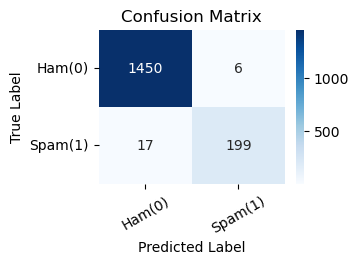

In [15]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(3,2))
g = sns.heatmap(cm, cmap='Blues', annot=True, fmt='g')
g.set_xticklabels(labels=['Ham(0)','Spam(1)'],rotation=30)
g.set_yticklabels(labels=['Ham(0)','Spam(1)'],rotation=0)
plt.ylabel('True Label',fontsize=10)
plt.xlabel('Predicted Label',fontsize=10)
plt.title('Confusion Matrix',fontsize=12)
plt.show()

In [16]:
emails = ['Hey Ali, can we get together to watch football game tomorrow?',
          'Upto 20% discount book, exclusive offer just for you. Dont miss this reward!']
emails_vect = vect.transform(emails)
model.predict(emails_vect)

array([0, 1])

In [17]:
email1 = ['Hey Ali, can we get together for a football match tomorrow?']
email1_vect = vect.transform(email1)
pred1 = model.predict(email1_vect)
if pred1==1:
    print('Email is spam')
else:
    print('Email is ham')

Email is ham


In [18]:
email2 = ['Upto 20% discount on book, exclusive offer just for you. Dont miss this reward!']
email2_vect = vect.transform(email2)
pred2 = model.predict(email2_vect)
if pred2==1:
    print('Email is spam')
else:
    print('Email is ham')

Email is spam


In [19]:
from sklearn.pipeline import Pipeline

In [20]:
clf = Pipeline([
    ('Vectorizer',CountVectorizer()),
    ('NB',MultinomialNB())
])

In [21]:
clf.fit(X_train,y_train)
clf.score(X_test,y_test)

0.986244019138756

In [22]:
emails = ['Hey, Ali can we get together for a football match tomorrow?',
          'Upto 20% discount on book, exclusive offer just for you. Dont miss this reward!']
clf.predict(emails)

array([0, 1])